In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/forecast_ready.csv", parse_dates=["Date"])
df.shape


(417049, 27)

In [2]:
#Load elasticity tables
regime_elasticity = pd.read_csv("../outputs/tables/regime_elasticity.csv")
store_elasticity = pd.read_csv("../outputs/tables/store_elasticity.csv")

regime_elasticity, store_elasticity.head()


(     regime  elasticity        r2   n_obs
 0  volatile   -0.101426  0.602873   48722
 1   decline   -0.067146  0.536484  104262
 2    stable   -0.036730  0.492894  159803
 3    growth   -0.041573  0.533079  104262,
    Store  elasticity        r2
 0      2   -0.087851  0.637029
 1      3   -0.086055  0.686785
 2     11   -0.036762  0.582909
 3     12   -0.061527  0.646038
 4     13   -0.068134  0.657678)

In [3]:
#Merge regime elasticity back
df = df.merge(regime_elasticity[["regime", "elasticity"]], on="regime", how="left")
df.rename(columns={"elasticity": "regime_elasticity"}, inplace=True)

df[["regime", "regime_elasticity"]].head()


,regime,regime_elasticity
0,volatile,-0.101426
1,volatile,-0.101426
2,decline,-0.067146
3,volatile,-0.101426
4,decline,-0.067146


In [4]:
#Baseline revenue
df["price"] = df["price_proxy"]
df["sales"] = np.exp(df["log_sales"])

df["revenue"] = df["price"] * df["sales"]
df["revenue"].describe()


count    417049.000000
mean       6035.466784
std        2332.419721
min         297.000000
25%        4435.000000
50%        5646.000000
75%        7190.150000
max       41551.000000
Name: revenue, dtype: float64

In [5]:
#Define price shocks
price_changes = [-0.10, -0.05, 0, 0.05, 0.10]

In [7]:
#Simulate demand under price changes
sim_results = []

for pct in price_changes:
    temp = df.copy()
    
    temp["new_price"] = temp["price"] * (1 + pct)
    
    temp["new_sales"] = temp["sales"] * (1 + temp["regime_elasticity"] * pct)
    
    temp["new_revenue"] = temp["new_price"] * temp["new_sales"]
    
    sim_results.append({
        "price_change": pct,
        "avg_price": temp["new_price"].mean(),
        "avg_sales": temp["new_sales"].mean(),
        "avg_revenue": temp["new_revenue"].mean()
    })

sim_df = pd.DataFrame(sim_results)
sim_df



,price_change,avg_price,avg_sales,avg_revenue
0,-0.10,0.839736,6593.757889,5459.612801
1,-0.05,0.886388,6576.979726,5748.309034
2,0.00,0.933040,6560.201564,6035.466784
3,0.05,0.979692,6543.423401,6321.086051
4,0.10,1.026344,6526.645239,6605.166835


In [8]:
sim_df.to_csv("../outputs/tables/price_simulation_summary.csv", index=False)


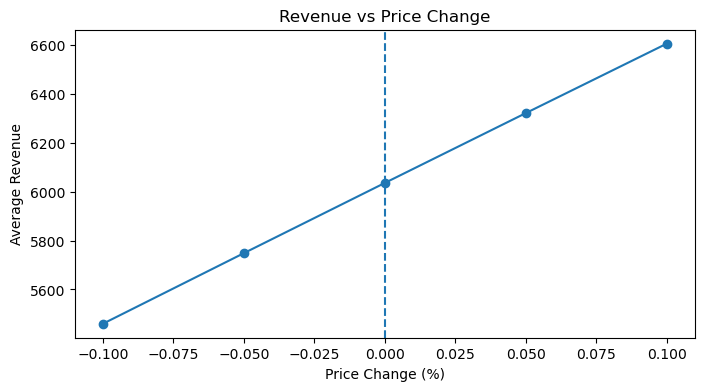

In [9]:
#Revenue curve
plt.figure(figsize=(8,4))
plt.plot(sim_df["price_change"], sim_df["avg_revenue"], marker="o")
plt.axvline(0, linestyle="--")
plt.title("Revenue vs Price Change")
plt.xlabel("Price Change (%)")
plt.ylabel("Average Revenue")
plt.show()


In [10]:
#Regime level simulation
regime_sim = []

for r in df["regime"].unique():
    sub = df[df["regime"] == r]
    
    for pct in price_changes:
        temp = sub.copy()
        
        temp["new_price"] = temp["price"] * (1 + pct)
        temp["new_sales"] = temp["sales"] * (1 + temp["regime_elasticity"] * pct)
        temp["new_revenue"] = temp["new_price"] * temp["new_sales"]
        
        regime_sim.append({
            "regime": r,
            "price_change": pct,
            "avg_revenue": temp["new_revenue"].mean()
        })

regime_sim_df = pd.DataFrame(regime_sim)
regime_sim_df.head()


,regime,price_change,avg_revenue
0,volatile,-0.10,5426.152155
1,volatile,-0.05,5698.850417
2,volatile,0.00,5968.521875
3,volatile,0.05,6235.166529
4,volatile,0.10,6498.784380


In [11]:
regime_sim_df.to_csv("../outputs/tables/regime_price_simulation.csv", index=False)


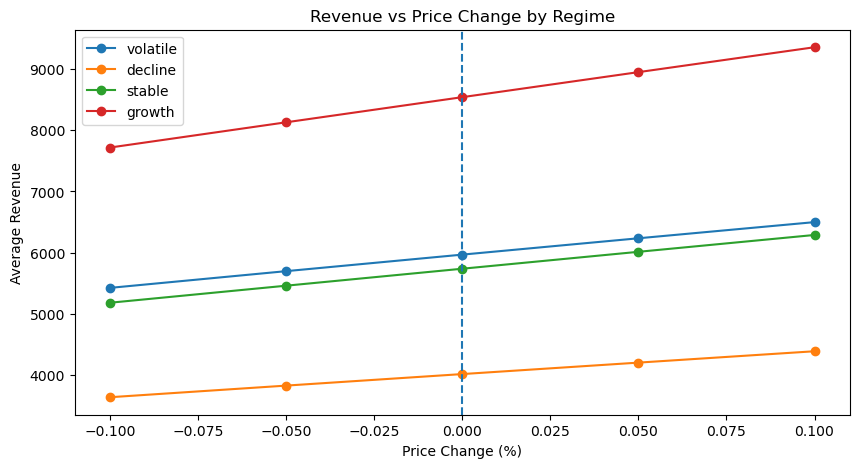

In [12]:
plt.figure(figsize=(10,5))

for r in regime_sim_df["regime"].unique():
    sub = regime_sim_df[regime_sim_df["regime"] == r]
    plt.plot(sub["price_change"], sub["avg_revenue"], marker="o", label=r)

plt.axvline(0, linestyle="--")
plt.legend()
plt.title("Revenue vs Price Change by Regime")
plt.xlabel("Price Change (%)")
plt.ylabel("Average Revenue")
plt.show()


In [13]:
#Find optimal price change
best = sim_df.loc[sim_df["avg_revenue"].idxmax()]
best


price_change       0.100000
avg_price          1.026344
avg_sales       6526.645239
avg_revenue     6605.166835
Name: 4, dtype: float64

In [14]:
df.to_csv("../data/processed/final_model_output.csv", index=False)
